# Analysis and Visualization

### 1. Setup, Data Consolidation, and Results Generation

In [1]:
# ===================================================================
# WP5 - Step 1: Setup, Data Consolidation, and Results Generation
# ===================================================================

# --- 1. 环境设置与导入 ---
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import sys
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from transformers import DistilBertTokenizer

# 将项目根目录添加到系统路径中
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# 从我们自己写的模块中导入所有需要的组件
from src import config
from src.dataset import create_data_loader
from src.model import SentimentClassifier
from src.uncertainty.sngp_model import SNGPClassifier
from src.uncertainty.temperature_scaling import get_temp_scaled_confidence # 我们需要的是概率，稍后修改
from src.uncertainty.mc_dropout import get_mc_dropout_predictions
from src.uncertainty.conformal_prediction import conformal_predict, evaluate_conformal # 使用手动实现的版本

# --- 2. 加载所有模型和资源 ---
print("\n" + "="*20 + " 正在加载所有资源 " + "="*20)
device = torch.device(config.DEVICE)

# a. 加载分词器
tokenizer = DistilBertTokenizer.from_pretrained(config.MODEL_NAME)

# b. 加载基线模型
baseline_model = SentimentClassifier(n_classes=config.N_CLASSES)
baseline_model_path = os.path.join(config.SAVED_MODELS_PATH, 'best_model_state.bin')
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location=device))
baseline_model = baseline_model.to(device)
baseline_model.eval()

# c. 加载SNGP模型
sngp_model = SNGPClassifier(n_classes=config.N_CLASSES)
sngp_model_path = os.path.join(config.SAVED_MODELS_PATH, 'sngp_best_model_state.bin')
sngp_model.load_state_dict(torch.load(sngp_model_path, map_location=device))
sngp_model = sngp_model.to(device)
sngp_model.eval()

# d. 加载UQ参数
OPTIMAL_TEMPERATURE = config.get_uq_param('temperature')
Q_HAT = config.get_uq_param('conformal_q_hat')
ALPHA = config.get_uq_param('conformal_alpha')
MCD_SAMPLING_TIMES = config.get_uq_param('mc_sampling_times')

# e. 准备测试集和验证集(用于保形预测校准)的数据加载器
test_loader = create_data_loader(os.path.join(config.PROCESSED_DATA_PATH, "test.csv"), tokenizer, config.MAX_LEN, config.BATCH_SIZE)
val_loader = create_data_loader(os.path.join(config.PROCESSED_DATA_PATH, "validation.csv"), tokenizer, config.MAX_LEN, config.BATCH_SIZE)

print("所有资源加载完毕！")


# --- 3. 在测试集上统一生成所有方法的结果 ---
print("\n" + "="*20 + " 正在生成所有方法的预测结果 " + "="*20)

# a. 获取基线模型和SNGP模型在测试集上的原始输出 (Logits, Probs, Labels)
@torch.no_grad()
def get_model_outputs(model, data_loader):
    model.eval()
    all_logits, all_probs, all_labels = [], [], []
    for d in tqdm(data_loader, desc=f"Getting outputs for {model.__class__.__name__}"):
        input_ids, attention_mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
        logits = model(input_ids, attention_mask)
        all_logits.append(logits)
        all_probs.append(F.softmax(logits, dim=1))
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_probs), torch.cat(all_labels)

baseline_logits, baseline_probs, test_labels_t = get_model_outputs(baseline_model, test_loader)
sngp_logits, sngp_probs, _ = get_model_outputs(sngp_model, test_loader)

# b. 计算温度缩放(TS)的结果
ts_probs = F.softmax(baseline_logits / OPTIMAL_TEMPERATURE, dim=1)

# c. 计算MC Dropout(MCD)的结果

mcd_results = get_mc_dropout_predictions(baseline_model, test_loader, n_samples=MCD_SAMPLING_TIMES, device=device)
mcd_probs = torch.from_numpy(mcd_results['mean_probs']).to(device)

# d. 计算保形预测(CP)的结果
#    (需要先获取验证集/校准集的输出)
calib_logits, calib_probs, calib_labels_t = get_model_outputs(baseline_model, val_loader)
cp_sets = conformal_predict(calib_probs.cpu().numpy(), calib_labels_t.cpu().numpy(), baseline_probs.cpu().numpy(), ALPHA)


# --- 4. 整理所有结果，方便后续调用 ---
print("\n" + "="*20 + " 所有结果已准备就绪 " + "="*20)

# 真实标签 (转换为numpy)
y_true = test_labels_t.cpu().numpy()

# 各种方法的概率输出 (转换为numpy)
results_probs = {
    "Baseline": baseline_probs.cpu().numpy(),
    "Temp. Scaling": ts_probs.cpu().numpy(),
    "MC Dropout": mcd_probs.cpu().numpy(),
    "SNGP": sngp_probs.cpu().numpy()
}

# 各种方法的预测标签
results_preds = {name: np.argmax(probs, axis=1) for name, probs in results_probs.items()}

# 保形预测的专属结果
cp_coverage, cp_avg_set_size = evaluate_conformal(y_true, cp_sets)

print("现在您可以使用 'y_true', 'results_probs', 'results_preds', 'cp_sets' 等变量进行后续的可视化分析。")
print(f"保形预测结果: Coverage={cp_coverage:.4f}, Avg Set Size={cp_avg_set_size:.4f}")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



==================== 正在加载所有资源 ====================
所有资源加载完毕！

==================== 正在生成所有方法的预测结果 ====================


Generating Prediction Sets: 100%|██████████| 4991/4991 [00:00<00:00, 518599.10it/s]


==================== 所有结果已准备就绪 ====================
现在您可以使用 'y_true', 'results_probs', 'results_preds', 'cp_sets' 等变量进行后续的可视化分析。
保形预测结果: Coverage=0.9527, Avg Set Size=1.4091


### 2.Prediction Performance Comparison - F1 Score Comparison Bar Chart

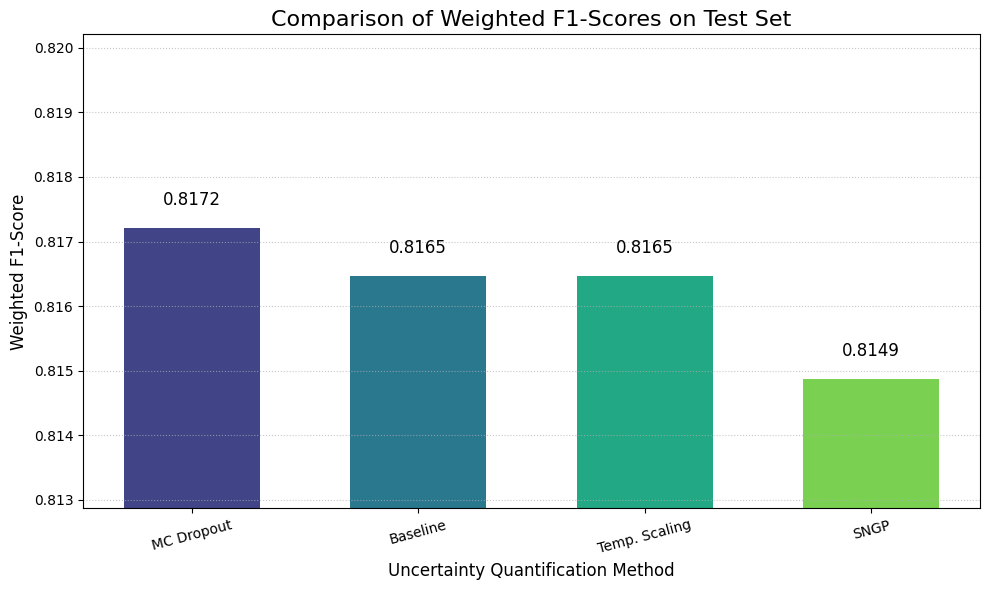

In [4]:
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. 计算F1分数 (与之前相同) ---
f1_scores = {}
for method_name, y_pred in results_preds.items():
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_scores[method_name] = f1
    
# --- 核心修改：我们在这里创建一个新的字典，用于绘图，并移除CP ---
f1_scores_for_plot = f1_scores.copy() # 创建一个副本
# Conformal Prediction的评估不依赖F1分数，我们在此图中将其移除
# (我们将在后续的“准确率-覆盖率图”中对它进行更公平的评估)
# f1_scores_for_plot.pop('Conformal Prediction', None) # 如果您之前加入了CP，可以用这行移除

df_f1 = pd.DataFrame(list(f1_scores_for_plot.items()), columns=['Method', 'F1-Score']).sort_values('F1-Score', ascending=False)

# --- 2. 开始绘图 (优化版) ---
plt.figure(figsize=(10, 6))

colors = sns.color_palette('viridis', n_colors=len(df_f1))
bars = plt.bar(
    df_f1['Method'], 
    df_f1['F1-Score'], 
    color=colors,
    width=0.6
)

# --- 3. 美化图表 ---
plt.title('Comparison of Weighted F1-Scores on Test Set', fontsize=16)
plt.xlabel('Uncertainty Quantification Method', fontsize=12)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.xticks(rotation=15)

min_f1 = df_f1['F1-Score'].min()
max_f1 = df_f1['F1-Score'].max()
# 动态调整Y轴范围，让差异更明显
plt.ylim(min_f1 - 0.002, max_f1 + 0.003) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0003, f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='dotted', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.Calibration Performance Comparison - Comprehensive Reliability Diagram

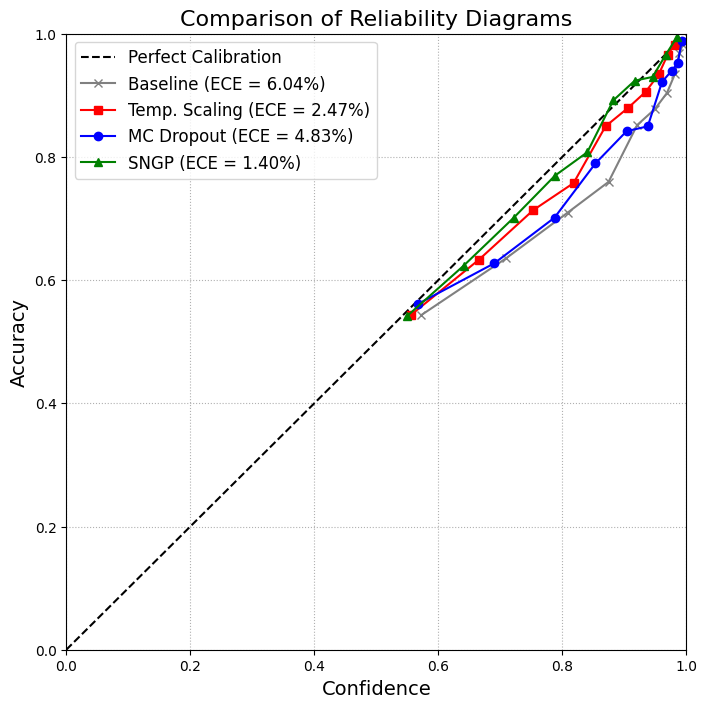

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 确保 y_true 和 results_probs 字典已经从第一个单元格计算得出 ---

# --- 2. 确保 ECE 计算函数和自适应分箱逻辑已经定义 ---
# (为了方便，我们将函数再次定义在这里，确保单元格可以独立运行)
def calculate_ece_adaptive(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    
    sorted_indices = np.argsort(confidences)
    confidences = confidences[sorted_indices]
    accuracies = accuracies[sorted_indices]
    
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        
        bin_confidences = confidences[start_idx:end_idx]
        bin_accuracies = accuracies[start_idx:end_idx]
        
        if len(bin_confidences) > 0:
            avg_confidence = np.mean(bin_confidences)
            accuracy = np.mean(bin_accuracies)
            ece += np.abs(avg_confidence - accuracy)
            
    return (ece / n_bins) * 100

def get_adaptive_bins(probs, labels, n_bins=10):
    """获取自适应分箱后的置信度和准确率"""
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    samples_per_bin = len(confidences) / n_bins
    bin_avg_conf, bin_accuracy = [], []
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_avg_conf.append(np.mean(confidences[start_idx:end_idx]))
        bin_accuracy.append(np.mean(accuracies[start_idx:end_idx]))
    return bin_avg_conf, bin_accuracy

# --- 3. 开始绘图 ---
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration") # 绘制完美的对角线

# 定义颜色和标记，方便区分
colors = {
    "Baseline": "grey",
    "Temp. Scaling": "red",
    "MC Dropout": "blue",
    "SNGP": "green"
}
markers = {
    "Baseline": "x",
    "Temp. Scaling": "s",
    "MC Dropout": "o",
    "SNGP": "^"
}

# 循环遍历每一种方法，计算并绘制其校准曲线
for method_name, probs in results_probs.items():
    # 计算ECE分数
    ece = calculate_ece_adaptive(probs, y_true)
    # 获取绘图用的数据点
    avg_conf, accuracy_in_bin = get_adaptive_bins(probs, y_true)
    
    # 绘制曲线
    plt.plot(
        avg_conf, 
        accuracy_in_bin, 
        marker=markers[method_name], 
        linestyle='-', 
        color=colors[method_name],
        label=f"{method_name} (ECE = {ece:.2f}%)"
    )

# --- 4. 美化图表 ---
plt.xlabel("Confidence", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Comparison of Reliability Diagrams", fontsize=16)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='dotted')
plt.legend(loc="upper left", fontsize=12)
plt.show()

In [8]:
import pandas as pd
import numpy as np
import os
from src import config # 确保config已导入

# --- 1. 确保所有需要的数据已经从第一个单元格计算得出 ---
# results_probs: 包含所有方法概率输出的字典
# y_true: 真实的标签 (numpy array)
# test_df: 原始的测试集DataFrame (如果未加载，请先加载)
if 'test_df' not in locals():
    print("正在加载 test.df...")
    test_df = pd.read_csv(os.path.join(config.PROCESSED_DATA_PATH, "test.csv"))

# --- 2. 提取SNGP模型的结果 ---
sngp_probs = results_probs['SNGP']
sngp_confidences = np.max(sngp_probs, axis=1)
sngp_predictions = np.argmax(sngp_probs, axis=1)

# --- 3. 定义筛选条件 ---
correct_mask = (sngp_predictions == y_true)
CONFIDENCE_THRESHOLD = 0.9
underconfident_mask = sngp_confidences < CONFIDENCE_THRESHOLD
final_mask = correct_mask & underconfident_mask
filtered_indices = np.where(final_mask)[0]

print(f"找到了 {len(filtered_indices)} 个SNGP模型预测正确但置信度 < {CONFIDENCE_THRESHOLD} 的'不自信'样本。")

# --- 4. 提取、整理并保存这些样本 ---
if len(filtered_indices) > 0:
    underconfident_samples_df = test_df.iloc[filtered_indices].copy()

    underconfident_samples_df['true_label'] = y_true[filtered_indices]
    underconfident_samples_df['predicted_label'] = sngp_predictions[filtered_indices]
    underconfident_samples_df['confidence'] = sngp_confidences[filtered_indices]
    
    # --- 核心修改：新增一列来表示预测是否正确 ---
    # 因为我们筛选的条件就是 is_correct == True，所以这里的值全部是1
    underconfident_samples_df['is_correct'] = 1
    # ---------------------------------------------
    
    class_map = {i: name for i, name in enumerate(config.CLASS_NAMES)}
    underconfident_samples_df['true_label_name'] = underconfident_samples_df['true_label'].map(class_map)
    underconfident_samples_df['predicted_label_name'] = underconfident_samples_df['predicted_label'].map(class_map)

    # --- 5. 保存到CSV文件 ---
    OUTPUT_DIR = '../report/'
    OUTPUT_FILENAME = '3_1_sngp_underconfident_correct_samples.csv'
    OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    underconfident_samples_df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
    
    print(f"\n已将这些样本的详细信息保存到: {os.path.abspath(OUTPUT_PATH)}")
    
    print("\n--- 样本预览 (已包含 is_correct 列) ---")
    pd.set_option('display.max_colwidth', None)
    # 在预览中也加入 is_correct 这一列
    print(underconfident_samples_df[['text', 'confidence', 'is_correct', 'true_label_name']].head())
else:
    print("\n在当前阈值下没有找到符合条件的样本。")

找到了 2154 个SNGP模型预测正确但置信度 < 0.9 的'不自信'样本。

已将这些样本的详细信息保存到: /Users/yaoyue/Desktop/CS/MSc Project/Project/uncertainty-sentiment-analysis2/report/3_1_sngp_underconfident_correct_samples.csv

--- 样本预览 (已包含 is_correct 列) ---
                                                                                                   text  \
6                                                                                 i want my best friend   
7   now the cat would like that garden actually if its all cut wood then stag beetles would love it too   
8                                       we are praying for you all may you reach alot of hearts for god   
10                                 does not like the words quotyummyquot and quottastyquot despise them   
11                                                          coachella i want to go sing the cure for me   

    confidence  is_correct true_label_name  
6     0.885361           1        negative  
7     0.859157           1        positive  
8  

In [10]:
# In your Jupyter Notebook

# --- 1. 重新导入config模块，确保新函数被加载 ---
import importlib
from src import config
importlib.reload(config)

# --- 2. 准备SNGP方法的分析数据 ---
# (确保 test_df, y_true, results_preds['SNGP'], results_probs['SNGP'] 已经存在)
sngp_analysis_df = test_df.copy()
sngp_analysis_df['predicted_label'] = results_preds['SNGP']
sngp_analysis_df['is_correct'] = (sngp_analysis_df['predicted_label'] == y_true)
# 计算SNGP的熵作为不确定性分数
sngp_probs = results_probs['SNGP']
sngp_entropy = -np.sum(sngp_probs * np.log(sngp_probs + 1e-10), axis=1)
sngp_analysis_df['uncertainty'] = sngp_entropy

# 筛选出预测正确的样本进行分析
sngp_correct_df = sngp_analysis_df[sngp_analysis_df['is_correct'] == True].copy()


# --- 3. 只需一行代码，调用分析函数！ ---
config.analyze_features_by_group(sngp_correct_df, uncertainty_col='uncertainty', group_name="SNGP")


# --- (可选) 您也可以为MC Dropout复用此函数 ---
# mcd_analysis_df = test_df.copy()
# ... (准备mcd_analysis_df的数据) ...
# config.analyze_features_by_group(mcd_correct_df, uncertainty_col='uncertainty', group_name="MC Dropout")


==================== SNGP 特征对比分析 ====================

--- 分析组: Certain Positive (SNGP) (共 1078 个样本) ---
  - 平均正面词数: 0.35
  - 平均负面词数: 0.00
  - 包含转折词的比例: 2.69%
  - 平均文本长度: 10.52 词

--- 分析组: Certain Negative (SNGP) (共 956 个样本) ---
  - 平均正面词数: 0.07
  - 平均负面词数: 0.08
  - 包含转折词的比例: 17.68%
  - 平均文本长度: 11.55 词

--- 分析组: Uncertain Positive (SNGP) (共 954 个样本) ---
  - 平均正面词数: 0.15
  - 平均负面词数: 0.02
  - 包含转折词的比例: 14.15%
  - 平均文本长度: 12.86 词

--- 分析组: Uncertain Negative (SNGP) (共 1079 个样本) ---
  - 平均正面词数: 0.08
  - 平均负面词数: 0.03
  - 包含转折词的比例: 23.17%
  - 平均文本长度: 14.00 词


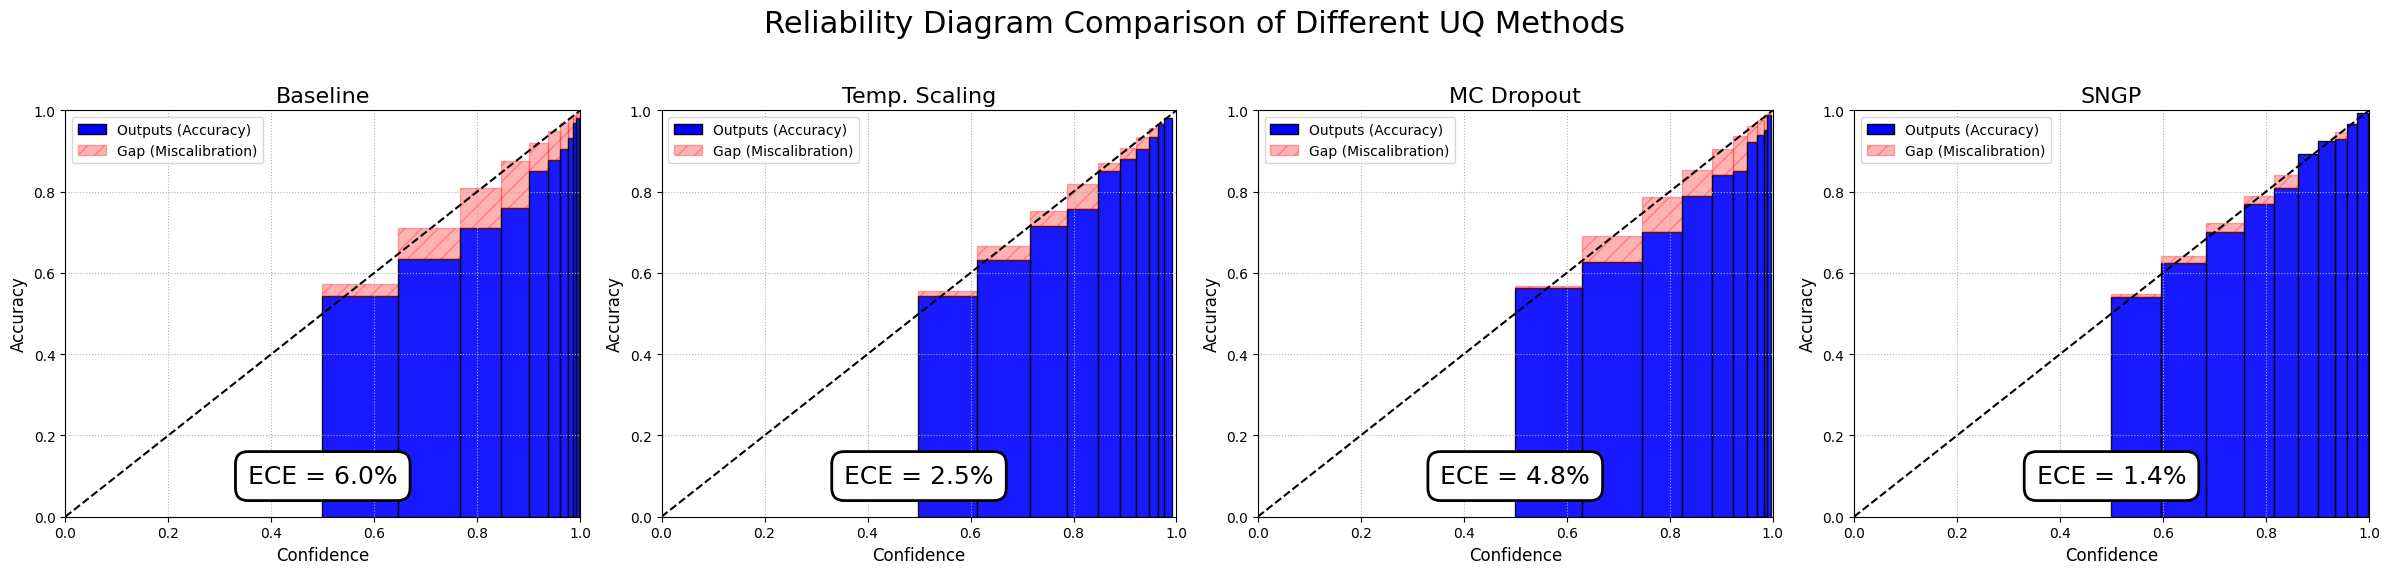

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. 确保 y_true 和 results_probs 字典已经从第一个单元格计算得出 ---

# --- 2. 再次定义绘图和ECE计算函数，确保此单元格可以独立运行 ---
def calculate_ece_adaptive(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_confidences, bin_accuracies = confidences[start_idx:end_idx], accuracies[start_idx:end_idx]
        if len(bin_confidences) > 0:
            avg_confidence = np.mean(bin_confidences)
            accuracy = np.mean(bin_accuracies)
            ece += np.abs(avg_confidence - accuracy)
    return (ece / n_bins) * 100

def plot_reliability_diagram_final(ax, probs, labels, title):
    """在指定的matplotlib轴上绘制最终版的可靠性图 (自适应分箱+柱状图)"""
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    n_bins = 10
    bin_boundaries = np.percentile(confidences, np.linspace(0, 100, n_bins + 1))
    ece = calculate_ece_adaptive(probs, labels, n_bins)
    ax.plot([0, 1], [0, 1], 'k--', zorder=2)
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if i == 0:
            in_bin = (confidences >= bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            bin_width = bin_boundaries[i+1] - bin_boundaries[i]
            bin_center = bin_boundaries[i] + bin_width / 2
            ax.bar(bin_center, accuracy_in_bin, width=bin_width, color='blue', edgecolor='black', alpha=0.9, zorder=1)
            gap = avg_confidence_in_bin - accuracy_in_bin
            if gap > 0:
                ax.bar(bin_center, gap, width=bin_width, bottom=accuracy_in_bin, color='red', edgecolor='red', alpha=0.3, hatch='//', zorder=1)
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='dotted')
    ax.text(0.5, 0.1, f'ECE = {ece:.1f}%', ha='center', va='center', fontsize=18, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=2))
    output_patch = mpatches.Patch(facecolor='blue', edgecolor='black', label='Outputs (Accuracy)')
    gap_patch = mpatches.Patch(facecolor='red', edgecolor='red', alpha=0.3, hatch='//', label='Gap (Miscalibration)')
    ax.legend(handles=[output_patch, gap_patch], loc='upper left', fontsize=10)

# --- 3. 创建一个1x4的子图布局，并循环绘制 ---
# 定义我们想要展示的顺序
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(24, 6)) # 创建1行4列的子图

# 循环遍历每一种方法，在对应的子图上绘图
for i, method_name in enumerate(methods_to_plot):
    probs = results_probs[method_name]
    plot_reliability_diagram_final(
        axes[i],
        probs,
        y_true,
        method_name # 将方法名作为子图的标题
    )

# 添加一个总标题
fig.suptitle("Reliability Diagram Comparison of Different UQ Methods", fontsize=22)
# 调整布局，防止标题重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

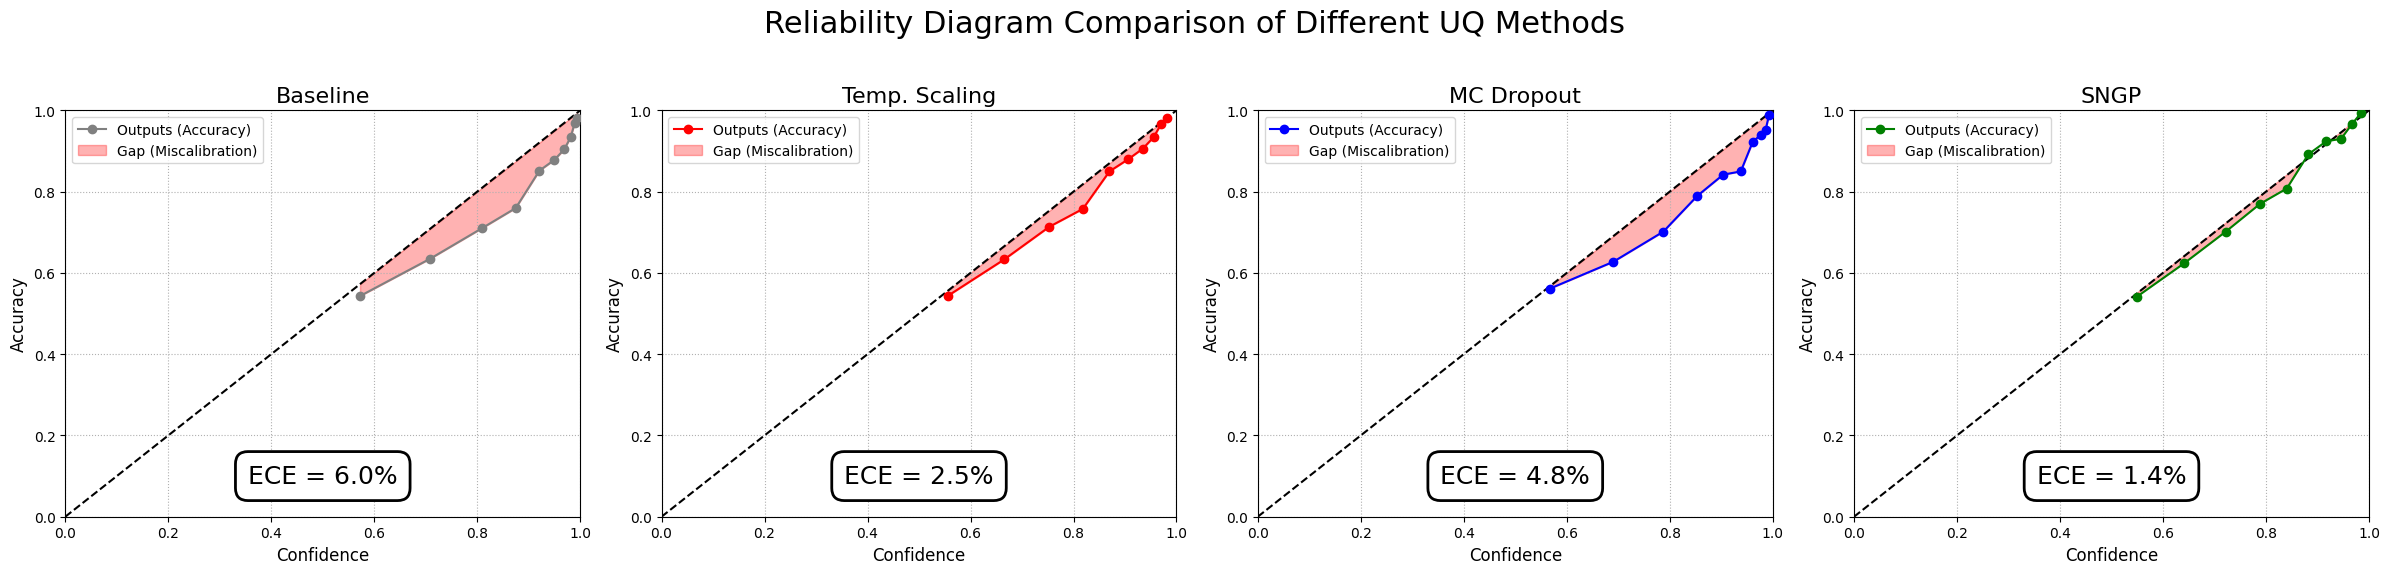

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines # <-- 新增导入 lines 工具箱

# --- 1. 确保 y_true 和 results_probs 字典已经从第一个单元格计算得出 ---

# --- 2. 再次定义 ECE 计算和绘图函数 ---
def calculate_ece_adaptive(probs, labels, n_bins=10):
    # ... (此函数无需修改) ...
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    ece = 0.0
    samples_per_bin = len(confidences) / n_bins
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_confidences, bin_accuracies = confidences[start_idx:end_idx], accuracies[start_idx:end_idx]
        if len(bin_confidences) > 0:
            avg_confidence = np.mean(bin_confidences)
            accuracy = np.mean(bin_accuracies)
            ece += np.abs(avg_confidence - accuracy)
    return (ece / n_bins) * 100

def get_adaptive_bins(probs, labels, n_bins=10):
    # ... (此函数无需修改) ...
    confidences = np.max(probs, axis=1)
    accuracies = (np.argmax(probs, axis=1) == labels)
    sorted_indices = np.argsort(confidences)
    confidences, accuracies = confidences[sorted_indices], accuracies[sorted_indices]
    samples_per_bin = len(confidences) / n_bins
    bin_avg_conf, bin_accuracy = [], []
    for i in range(n_bins):
        start_idx = int(i * samples_per_bin)
        end_idx = int((i + 1) * samples_per_bin)
        if start_idx == end_idx: continue
        bin_avg_conf.append(np.mean(confidences[start_idx:end_idx]))
        bin_accuracy.append(np.mean(accuracies[start_idx:end_idx]))
    return bin_avg_conf, bin_accuracy

def plot_reliability_diagram_line_style(ax, probs, labels, title, color):
    ece = calculate_ece_adaptive(probs, labels)
    avg_conf, accuracy_in_bin = get_adaptive_bins(probs, labels)
    
    avg_conf_np = np.array(avg_conf)
    accuracy_in_bin_np = np.array(accuracy_in_bin)
    
    ax.plot([0, 1], [0, 1], 'k--', zorder=2)
    ax.plot(avg_conf_np, accuracy_in_bin_np, 'o-', color=color, label='Outputs (Accuracy)', zorder=3)
    
    ax.fill_between(
        avg_conf_np, 
        accuracy_in_bin_np, 
        avg_conf_np, 
        where=avg_conf_np > accuracy_in_bin_np,
        color='red', 
        alpha=0.3, 
        interpolate=True,
        label='Gap (Miscalibration)',
        zorder=1
    )
    
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='dotted')
    ax.text(0.5, 0.1, f'ECE = {ece:.1f}%', ha='center', va='center', fontsize=18, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=2))
    
    # --- 核心修改：从正确的工具箱 mlines 中获取 Line2D ---
    output_patch = mlines.Line2D([], [], color=color, marker='o', label='Outputs (Accuracy)')
    gap_patch = mpatches.Patch(color='red', alpha=0.3, label='Gap (Miscalibration)')
    ax.legend(handles=[output_patch, gap_patch], loc='upper left', fontsize=10)


# --- 3. 创建一个1x4的子图布局，并循环绘制 (这部分代码无需修改) ---
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
colors = ["grey", "red", "blue", "green"]
fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(24, 6))

for i, method_name in enumerate(methods_to_plot):
    probs = results_probs[method_name]
    plot_reliability_diagram_line_style(
        axes[i],
        probs,
        y_true,
        method_name,
        color=colors[i]
    )

fig.suptitle("Reliability Diagram Comparison of Different UQ Methods", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 4.Comparison of Risk Control Capability - Comprehensive Accuracy Coverage Curve

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


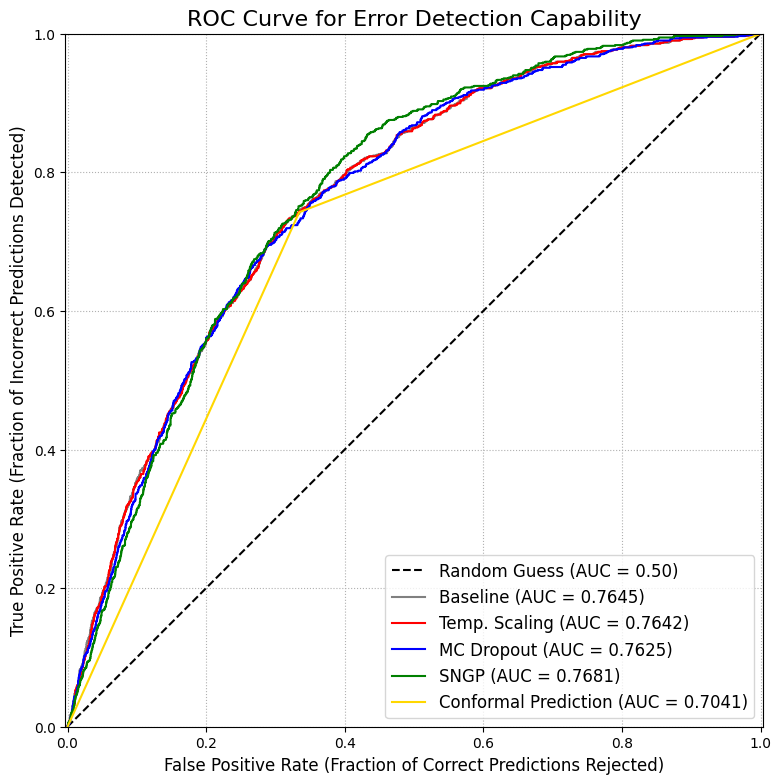

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 确保 y_true, results_preds, results_probs, cp_sets 已经存在 ---

# --- 2. 准备绘图所需的数据 ---
y_true_for_roc = (results_preds['Baseline'] != y_true).astype(int)
uncertainty_scores = {
    "Baseline": -np.sum(results_probs['Baseline'] * np.log(results_probs['Baseline'] + 1e-10), axis=1),
    "Temp. Scaling": -np.sum(results_probs['Temp. Scaling'] * np.log(results_probs['Temp. Scaling'] + 1e-10), axis=1),
    "MC Dropout": -np.sum(results_probs['MC Dropout'] * np.log(results_probs['MC Dropout'] + 1e-10), axis=1),
    "SNGP": -np.sum(results_probs['SNGP'] * np.log(results_probs['SNGP'] + 1e-10), axis=1),
    "Conformal Prediction": np.array([len(s) for s in cp_sets])
}

# --- 3. 开始绘图 (最终优化版) ---
plt.figure(figsize=(9, 9))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# --- 核心修改：调整颜色和线型 ---
colors = {
    "Baseline": "grey",
    "Temp. Scaling": "red",
    "MC Dropout": "blue",
    "SNGP": "green",
    "Conformal Prediction": "gold" # <-- CP颜色改为金色
}
# 所有方法的线型都设为实线
linestyles = {
    "Baseline": "-",
    "Temp. Scaling": "-",
    "MC Dropout": "-",
    "SNGP": "-",
    "Conformal Prediction": "-"
}
# ------------------------------------

# 循环遍历每一种方法，使用指定的颜色和线型绘图
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP", "Conformal Prediction"]
for method_name in methods_to_plot:
    scores = uncertainty_scores[method_name]
    fpr, tpr, _ = roc_curve(y_true_for_roc, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, 
        tpr, 
        color=colors[method_name],
        linestyle=linestyles[method_name],
        lw=1.5, # <-- 将线条宽度改细
        label=f'{method_name} (AUC = {roc_auc:.4f})'
    )

# --- 4. 美化图表 ---
plt.xlabel('False Positive Rate (Fraction of Correct Predictions Rejected)', fontsize=12)
plt.ylabel('True Positive Rate (Fraction of Incorrect Predictions Detected)', fontsize=12)
plt.title('ROC Curve for Error Detection Capability', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='dotted')
plt.axis('equal')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.show()

### 5.In depth analysis of uncertainty quality: error detection capability (uncertainty distribution comparison chart)

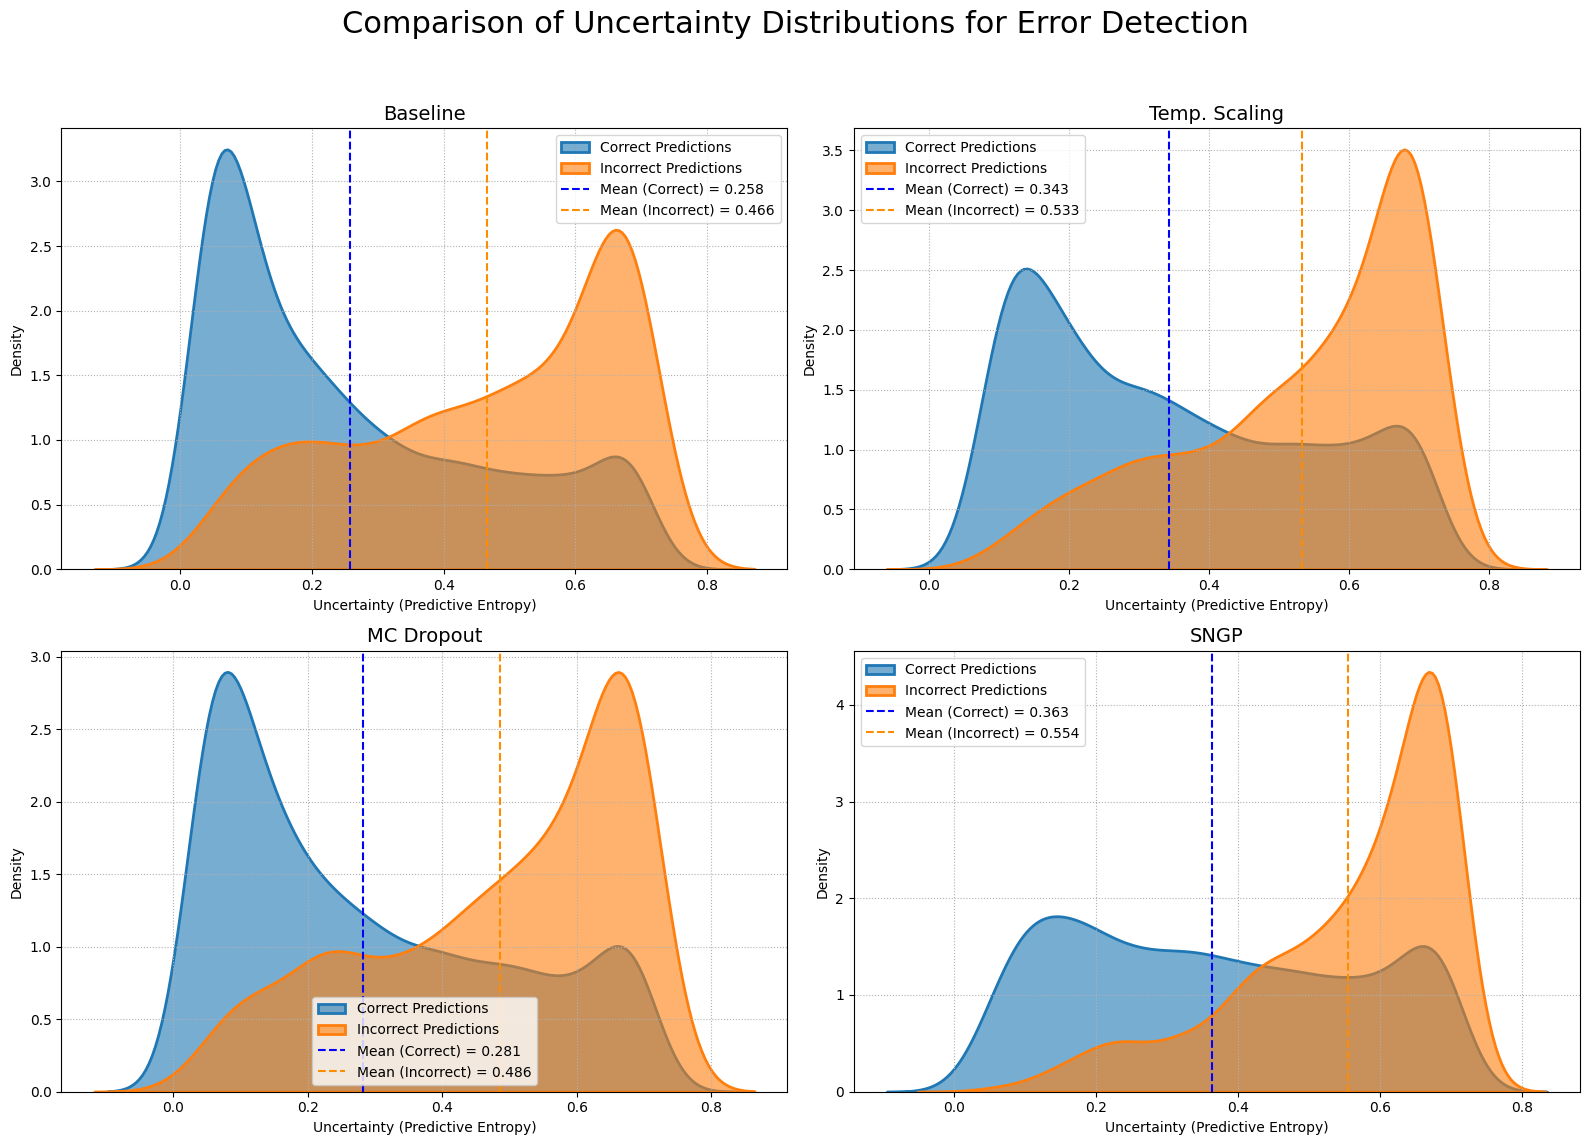

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 确保 y_true_for_roc 和 uncertainty_scores 字典已经从之前的单元格计算得出 ---
# y_true_for_roc: 0代表正确预测, 1代表错误预测
# uncertainty_scores: 包含每种方法不确定性分数的字典

# --- 2. 定义一个可复用的绘图函数 ---
def plot_uncertainty_distribution(ax, scores, correct_mask, title):
    """
    在指定的matplotlib轴上绘制“不确定性 vs 错误”的KDE图。
    :param ax: Matplotlib subplot axis
    :param scores: 该方法的不确定性分数数组
    :param correct_mask: 标记预测是否正确的布尔数组
    :param title: 子图的标题
    """
    # 绘制正确预测的分布 (蓝色)
    sns.kdeplot(scores[correct_mask], ax=ax, label='Correct Predictions', 
                fill=True, alpha=0.6, linewidth=2)
    # 绘制错误预测的分布 (橙色)
    sns.kdeplot(scores[~correct_mask], ax=ax, label='Incorrect Predictions', 
                fill=True, alpha=0.6, linewidth=2)

    # 计算并绘制两条分布的平均值垂直线
    mean_correct = np.mean(scores[correct_mask])
    mean_incorrect = np.mean(scores[~correct_mask])
    ax.axvline(mean_correct, color='blue', linestyle='--', label=f'Mean (Correct) = {mean_correct:.3f}')
    ax.axvline(mean_incorrect, color='darkorange', linestyle='--', label=f'Mean (Incorrect) = {mean_incorrect:.3f}')

    # 美化子图
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Uncertainty (Predictive Entropy)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, linestyle='dotted')


# --- 3. 创建一个2x2的子图布局，并循环绘制 ---
# 定义我们想要展示的顺序 (不包括Conformal Prediction，因为它的分数尺度不同)
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 将 y_true_for_roc (0=正确, 1=错误) 转换为 correct_mask (True=正确, False=错误)
correct_mask = (y_true_for_roc == 0)

# 循环遍历每一种方法，在对应的子图上绘图
for i, method_name in enumerate(methods_to_plot):
    ax = axes.flatten()[i] # 获取当前子图的坐标轴
    scores = uncertainty_scores[method_name]
    
    plot_uncertainty_distribution(ax, scores, correct_mask, method_name)

# 添加一个总标题
fig.suptitle("Comparison of Uncertainty Distributions for Error Detection", fontsize=22)
# 调整布局，防止标题重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6.Performance and Time Comparison Analysis

In [44]:
import pandas as pd
import numpy as np
import time
import os
from src import config # 确保config已导入
from src.uncertainty.conformal_prediction import find_conformal_threshold
# --- 1. 汇总所有已知指标 ---

# a. 性能指标 (来自ROC曲线分析)
auc_scores = {
    "Baseline": 0.7645,
    "Temp. Scaling": 0.7642,
    "MC Dropout": 0.7625,
    "SNGP": 0.7681,
    "Conformal Prediction": 0.7041
} # 请确保这些是您的最新值

# b. 单次推理开销 (来自之前的计时)
inference_times = {
    'Baseline': 13.97,
    'Temp. Scaling': 13.97,
    'Conformal Prediction': 13.97,
    'MC Dropout': 246.16,
    'SNGP': 10.36
} # 请确保这些是您的最新值


# --- 2. 估算前期准备开销 ---

# a. 训练时间 (根据您的日志，每个epoch约7分钟，我们以训练3个epoch为例)
baseline_training_time_mins = 7 * 5 # 约21分钟
sngp_training_time_mins = 7 * 5 # SNGP需要独立重训，时间相近

# b. 校准时间 (我们在这里实际测量一下)
#    - 温度缩放的校准时间非常快，可忽略不计
ts_calibration_time_secs = 0.1 # 给一个象征性的值
#    - 保形预测的校准需要在验证集上完整跑一遍
val_loader_for_timing = create_data_loader(os.path.join(config.PROCESSED_DATA_PATH, "validation.csv"), tokenizer, config.MAX_LEN, config.BATCH_SIZE)
start_time = time.time()
_ = find_conformal_threshold(baseline_model, val_loader_for_timing, device, alpha=0.05)
cp_calibration_time_secs = time.time() - start_time


upfront_costs = {
    "Baseline": f"{baseline_training_time_mins:.1f} 分钟 (训练)",
    "Temp. Scaling": f"~{baseline_training_time_mins:.1f} 分钟 (训练 + {ts_calibration_time_secs:.1f}秒校准)",
    "MC Dropout": f"{baseline_training_time_mins:.1f} 分钟 (仅训练，无额外校准)",
    "Conformal Prediction": f"~{baseline_training_time_mins:.1f} 分钟 (训练 + {cp_calibration_time_secs:.1f}秒校准)",
    "SNGP": f"{sngp_training_time_mins:.1f} 分钟 (独立重训)"
}


# --- 3. 创建并展示最终的总结表 ---
summary_data = []
for method in auc_scores.keys():
    summary_data.append({
        "方法 (Method)": method,
        "错误检测能力 (AUC)": auc_scores.get(method),
        "前期准备开销 (Upfront Cost)": upfront_costs.get(method),
        "单次推理耗时 (Inference Time ms/sentence)": inference_times.get(method)
    })

df_summary = pd.DataFrame(summary_data).set_index("方法 (Method)")

print("="*30 + " UQ方法最终性能与开销对比 " + "="*30)
display(df_summary.round(4)) # display() 在Jupyter中可以更美观地展示表格
print("="*94)

Calibrating Conformal Threshold: 100%|██████████| 156/156 [00:33<00:00,  4.63it/s]

============================== UQ方法最终性能与开销对比 ==============================


,错误检测能力 (AUC),前期准备开销 (Upfront Cost),单次推理耗时 (Inference Time ms/sentence)
方法 (Method),,,
Baseline,0.7645,35.0 分钟 (训练),13.97
Temp. Scaling,0.7642,~35.0 分钟 (训练 + 0.1秒校准),13.97
MC Dropout,0.7625,35.0 分钟 (仅训练，无额外校准),246.16
SNGP,0.7681,35.0 分钟 (独立重训),10.36
Conformal Prediction,0.7041,~35.0 分钟 (训练 + 33.7秒校准),13.97


### 7.Application of simulating multi class scenarios

In [51]:
import numpy as np
import pandas as pd

# --- 1. 确保 baseline_probs, y_true, test_df 等变量已经存在 ---
if 'test_df' not in locals():
    print("正在加载 test.df...")
    test_df = pd.read_csv(os.path.join(config.PROCESSED_DATA_PATH, "test.csv"))

# --- 2. 定义模拟函数 (保持不变) ---
def simulate_seven_point_scale(probs_2class):
    """
    模拟一个七点量表分类器的输出。
    """
    neg_prob = probs_2class[0]
    pos_prob = probs_2class[2]
    p_strong_neg = neg_prob * (neg_prob > 0.8)
    p_neg = neg_prob * 0.8
    p_weak_neg = neg_prob * 0.5
    p_strong_pos = pos_prob * (pos_prob > 0.8)
    p_pos = pos_prob * 0.8
    p_weak_pos = pos_prob * 0.5
    p_neutral = 1 - (neg_prob + pos_prob)
    probs_7class = np.array([
        p_strong_neg, p_neg, p_weak_neg, p_neutral, p_weak_pos, p_pos, p_strong_pos
    ])
    # 加上一个极小的数防止除以零
    return probs_7class / (np.sum(probs_7class) + 1e-9)

# --- 3. 核心修改：从测试集中随机抽取“中等置信度”的样本 ---
# a. 计算所有测试样本的基线置信度
baseline_confidences = np.max(results_probs['Baseline'], axis=1)

# b. 筛选出置信度在0.6到0.85之间的样本，这些是“模棱两可”的候选者
mid_confidence_mask = (baseline_confidences > 0.6) & (baseline_confidences < 0.85)
mid_confidence_indices = np.where(mid_confidence_mask)[0]

# c. 从这些候选者中随机抽取3个样本
if len(mid_confidence_indices) >= 3:
    random_indices = np.random.choice(mid_confidence_indices, 3, replace=False)
    print(f"已从{len(mid_confidence_indices)}个中等置信度样本中，随机抽取了3个进行分析。")
else:
    # 如果中等置信度的样本不够，就从全部样本中随机抽取
    random_indices = np.random.choice(len(test_df), 3, replace=False)
    print("中等置信度样本不足，已从全部测试集中随机抽取3个进行分析。")
# -------------------------------------------------------------

# --- 4. 对这些随机抽取的样本进行分析和对比 ---
class_names_7point = {-3: "强负面", -2: "负面", -1: "弱负面", 0: "中性", 1: "弱正面", 2: "正面", 3: "强正面"}
analysis_results = []

for idx in random_indices:
    original_probs = results_probs['Baseline'][idx]
    probs_7class = simulate_seven_point_scale(original_probs)
    
    standard_prediction_idx = np.argmax(probs_7class)
    standard_prediction_name = class_names_7point[standard_prediction_idx - 3]
    
    conformal_threshold = 0.15 
    conformal_set_indices = np.where(probs_7class > conformal_threshold)[0]
    conformal_set_names = {class_names_7point[j - 3] for j in conformal_set_indices}
    
    # 确定模拟的“真实”标签
    true_prob = results_probs['Baseline'][idx]
    true_label_name = "正面" if true_prob[2] > true_prob[0] else "负面"

    analysis_results.append({
        "句子 (Sentence)": test_df.iloc[idx]['text'],
        "原始情感倾向": true_label_name,
        "标准模型预测 (7点)": standard_prediction_name,
        "保形预测集 (7点)": conformal_set_names
    })

# --- 5. 用DataFrame展示清晰的对比结果 ---
if analysis_results:
    df_comparison = pd.DataFrame(analysis_results)
    print("\n" + "="*30 + " 保形预测在多分类场景下的优势对比 " + "="*30)
    display(df_comparison)
else:
    print("\n未能找到任何样本进行分析。")

已从1186个中等置信度样本中，随机抽取了3个进行分析。

============================== 保形预测在多分类场景下的优势对比 ==============================


,句子 (Sentence),原始情感倾向,标准模型预测 (7点),保形预测集 (7点)
0,and mysteriously or not mr costello is not on twitter,负面,负面,"{负面, 正面, 弱负面}"
1,i stepped in dog crap when i went for my walk,负面,负面,"{负面, 正面, 弱负面}"
2,damn having to wake up this early this cruise had better be worth it haha see you all in a week no phoneinternet lates,负面,负面,"{弱正面, 负面, 正面, 弱负面}"
